# Preparación del Entorno de Trabajo: IA en Ciberseguridad

## Introducción
Este cuaderno establece las bases del entorno de desarrollo necesario para implementar
soluciones avanzadas de seguridad basadas en Inteligencia Artificial.

### Requisitos Mínimos del Sistema
- **Python 3.8+** (recomendado 3.10 o superior)
- Las bibliotecas especificadas abajo deben estar disponibles en el entorno activo

## Configuración del Entorno Virtual
Aislamos las dependencias del proyecto en un entorno virtual independiente.

### Comandos de configuración
```bash
# Crear el entorno virtual
python -m venv sec_env

# Activación — Linux/macOS
source sec_env/bin/activate

# Activación — Windows
sec_env\Scripts\activate
```

## Instalación de Dependencias Principales
El stack de bibliotecas requeridas cubre desde procesamiento de datos hasta aprendizaje profundo.

### Stack de herramientas

| Librería | Rol principal |
| :--- | :--- |
| **NumPy** | Operaciones numéricas y arrays |
| **pandas** | Manipulación y análisis de DataFrames |
| **scikit-learn** | Algoritmos ML clásicos (RF, SVM, Árboles) |
| **TensorFlow/Keras** | Redes neuronales y modelos DL |
| **matplotlib/seaborn** | Visualización de datos |
| **pefile** | Análisis de ejecutables (PE) |
| **shap/lime** | Interpretabilidad de modelos (XAI) |
| **imbalanced-learn** | Balanceo de datasets desbalanceados |

## Validación del Entorno
Ejecutamos un script que verifica la disponibilidad de todas las bibliotecas críticas
y reporta sus versiones para confirmar compatibilidad.

In [1]:
import sys
import importlib

# Lista de paquetes requeridos
REQUIRED = [
    "numpy", "pandas", "sklearn", "matplotlib",
    "seaborn", "imblearn", "shap", "pefile", "joblib"
]

print(f"Python {sys.version}")
print("=" * 50)
all_ok = True
for pkg in REQUIRED:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "disponible")
        print(f"  [OK]    {pkg:<20} {version}")
    except ImportError:
        print(f"  [FALTA] {pkg}")
        all_ok = False

print("=" * 50)
print("Estado final:", "✓ Todo listo" if all_ok else "✗ Hay paquetes faltantes")

Python 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
  [OK]    numpy                2.4.4
  [OK]    pandas               3.0.2


  [OK]    sklearn              1.8.0
  [OK]    matplotlib           3.10.9


  [OK]    seaborn              0.13.2


  [OK]    imblearn             0.14.1
  [OK]    shap                 0.51.0
  [FALTA] pefile
  [OK]    joblib               1.5.3
Estado final: ✗ Hay paquetes faltantes


## Prueba funcional básica

Verificamos que cada biblioteca opera correctamente ejecutando una operación
representativa de lo que se usa en los cuadernos siguientes.

[numpy]     array shape=(100, 4), mean=0.4976
[pandas]    DataFrame (100, 4)


[sklearn]   IsolationForest entrenado, n_estimators=100


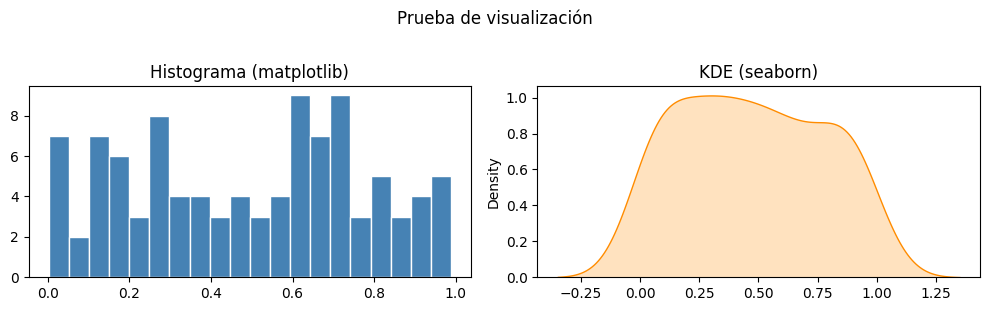

[matplotlib/seaborn] OK


In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ── Numpy: operación matricial ──────────────────────────────────────────
arr = np.random.rand(100, 4)
print(f"[numpy]     array shape={arr.shape}, mean={arr.mean():.4f}")

# ── Pandas: creación de DataFrame ──────────────────────────────────────
df = pd.DataFrame(arr, columns=["A", "B", "C", "D"])
print(f"[pandas]    DataFrame {df.shape}")

# ── scikit-learn: escalado + modelo ────────────────────────────────────
scaler = MinMaxScaler()
scaled = scaler.fit_transform(arr)
model = IsolationForest(random_state=42)
model.fit(scaled)
print(f"[sklearn]   IsolationForest entrenado, n_estimators={model.n_estimators}")

# ── Matplotlib / Seaborn: gráfico de prueba ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(arr[:, 0], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Histograma (matplotlib)")
sns.kdeplot(arr[:, 1], ax=axes[1], fill=True, color="darkorange")
axes[1].set_title("KDE (seaborn)")
plt.suptitle("Prueba de visualización", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("[matplotlib/seaborn] OK")

In [3]:
# ── imbalanced-learn: SMOTE ─────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
X_imb = np.vstack([np.random.randn(90, 4), np.random.randn(10, 4) + 5])
y_imb = np.array([0] * 90 + [1] * 10)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_imb, y_imb)
print(f"[imblearn]  SMOTE: {dict(zip(*np.unique(y_imb, return_counts=True)))} → "
      f"{dict(zip(*np.unique(y_res, return_counts=True)))}")

# ── shap ────────────────────────────────────────────────────────────────
import shap
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_res, y_res)
explainer = shap.TreeExplainer(rf)
svals = explainer.shap_values(X_res[:5])
print(f"[shap]      valores SHAP calculados, shape={np.array(svals).shape}")

# ── joblib ──────────────────────────────────────────────────────────────
import joblib, os
joblib.dump(rf, "/tmp/rf_test.pkl")
rf2 = joblib.load("/tmp/rf_test.pkl")
os.remove("/tmp/rf_test.pkl")
print(f"[joblib]    serialización/carga OK")

print("\n✓ Todas las bibliotecas funcionan correctamente.")

[imblearn]  SMOTE: {np.int64(0): np.int64(90), np.int64(1): np.int64(10)} → {np.int64(0): np.int64(90), np.int64(1): np.int64(90)}
[shap]      valores SHAP calculados, shape=(5, 4, 2)
[joblib]    serialización/carga OK

✓ Todas las bibliotecas funcionan correctamente.
